# Animal depiction annotation: label proportions by category

Reads `7k_animal_depiction_annotation_04302026.csv` and summarizes, per category, the fraction of rows labeled **skip**, **real-life** (`yes`), and **not real-life** (`no`).

Also reports **P(not real-life | not skip)** — among rows that are not `skip`, the fraction labeled not real-life (complements **P(real-life | not skip)** over the same non-skip set).

In [38]:
from pathlib import Path

import pandas as pd

# Project root: parent of analysis/preprint-2026
PROJECT_ROOT = Path.cwd().resolve().parents[1]
ANNOTATION_CSV = (
    PROJECT_ROOT
    / "annotation"
    / "annotation_data"
    / "7k_animal_depiction_annotation_04302026.csv"
)

df = pd.read_csv(ANNOTATION_CSV)
assert set(df.columns) >= {"category", "label"}

LABEL_MAP = {
    "yes": "real-life",
    "no": "not real-life",
    "skip": "skip",
}
unknown = set(df["label"].unique()) - set(LABEL_MAP)
if unknown:
    raise ValueError(f"Unexpected label values: {unknown}")

df["label_display"] = df["label"].map(LABEL_MAP)

PREPRINT_DIR = PROJECT_ROOT / "analysis" / "preprint-2026"
RUN_ROOT = PREPRINT_DIR / "supplemental_results_valid85s_04302026"
RESULTS_DIR = RUN_ROOT / "results"
FIGURES_DIR = RUN_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df.head()

,category,filename,relative_path,label,label_display
0,alligator,alligator_0.270_00430001_2023-08-23_1_c1a4695a...,alligator/alligator_0.270_00430001_2023-08-23_...,skip,skip
1,alligator,alligator_0.272_00370001_2024-08-24_1_6ef6f212...,alligator/alligator_0.272_00370001_2024-08-24_...,skip,skip
2,alligator,alligator_0.274_00400003_2023-12-17_2_f7d8a033...,alligator/alligator_0.274_00400003_2023-12-17_...,no,not real-life
3,alligator,alligator_0.275_00500001_2024-10-04_1_ca5ed548...,alligator/alligator_0.275_00500001_2024-10-04_...,skip,skip
4,alligator,alligator_0.276_00430001_2023-12-16_2_0636765b...,alligator/alligator_0.276_00430001_2023-12-16_...,skip,skip


In [39]:
# Counts and proportions per category (rows sum to 1.0 per category)
order = ["skip", "real-life", "not real-life"]
counts = (
    df.groupby(["category", "label_display"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)
totals = counts.sum(axis=1)
props = counts.div(totals, axis=0)

summary = counts.copy()
summary.columns = [f"n_{c}" for c in summary.columns]
for c in order:
    summary[f"p_{c}"] = props[c]
summary["n_total"] = totals
summary = summary.sort_index()

summary_path = RESULTS_DIR / "animal_depiction_label_proportions_by_category.csv"
summary.to_csv(summary_path, index_label="category")
print(f"Saved: {summary_path}")

summary.round({c: 4 for c in summary.columns if c.startswith("p_")})

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85s_04302026/results/animal_depiction_label_proportions_by_category.csv


,n_skip,n_real-life,n_not real-life,p_skip,p_real-life,p_not real-life,n_total
category,,,,,,,
alligator,61,0,39,0.61,0.00,0.39,100
bird,49,3,48,0.49,0.03,0.48,100
butterfly,9,2,89,0.09,0.02,0.89,100
cat,40,57,3,0.40,0.57,0.03,100
dog,29,55,16,0.29,0.55,0.16,100
frog,72,1,27,0.72,0.01,0.27,100
pony,33,0,67,0.33,0.00,0.67,100


In [40]:
# Among non-skip rows only: P(not real-life) and P(real-life) (they sum to 1 per category)
non_skip = df[df["label_display"] != "skip"]
order_ns = ["real-life", "not real-life"]
counts_ns = (
    non_skip.groupby(["category", "label_display"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order_ns, fill_value=0)
)
n_non_skip = counts_ns.sum(axis=1)
p_not_given_non_skip = counts_ns["not real-life"] / n_non_skip
p_real_given_non_skip = counts_ns["real-life"] / n_non_skip

cond_non_skip = pd.DataFrame(
    {
        "n_non_skip": n_non_skip.astype(int),
        "n_real-life": counts_ns["real-life"].astype(int),
        "n_not real-life": counts_ns["not real-life"].astype(int),
        "p_not real-life | not skip": p_not_given_non_skip,
        "p_real-life | not skip": p_real_given_non_skip,
    }
).sort_index()

cond_path = RESULTS_DIR / "animal_depiction_conditional_non_skip_by_category.csv"
cond_non_skip.to_csv(cond_path, index_label="category")
print(f"Saved: {cond_path}")

cond_non_skip.round(
    {c: 4 for c in cond_non_skip.columns if c.startswith("p_")}
)

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85s_04302026/results/animal_depiction_conditional_non_skip_by_category.csv


,n_non_skip,n_real-life,n_not real-life,p_not real-life | not skip,p_real-life | not skip
category,,,,,
alligator,39,0,39,1.0000,0.0000
bird,51,3,48,0.9412,0.0588
butterfly,91,2,89,0.9780,0.0220
cat,60,57,3,0.0500,0.9500
dog,71,55,16,0.2254,0.7746
frog,28,1,27,0.9643,0.0357
pony,67,0,67,1.0000,0.0000


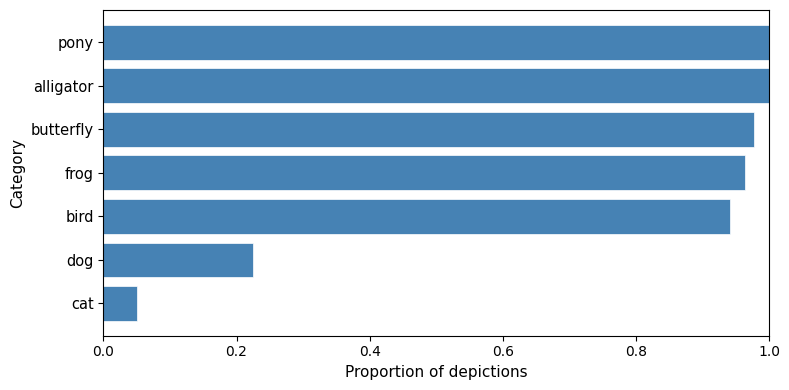

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85s_04302026/figures/animal_depiction_p_not_real_life_given_non_skip_by_category.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85s_04302026/figures/animal_depiction_p_not_real_life_given_non_skip_by_category.pdf


In [41]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

col = "p_not real-life | not skip"
s = cond_non_skip[col].dropna().sort_values(ascending=True)
fig_h = max(4.0, 0.45 * len(s))
fig, ax = plt.subplots(figsize=(8, fig_h))
ax.barh(s.index.astype(str), s.values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Proportion of depictions")
ax.set_ylabel("Category")
ax.set_xlim(0, 1)
fig.tight_layout()

out_path = FIGURES_DIR / "animal_depiction_p_not_real_life_given_non_skip_by_category.png"
out_pdf = out_path.with_suffix(".pdf")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Saved: {out_pdf}")

In [42]:
# Overall proportions (all rows)
overall = df["label_display"].value_counts(normalize=True).reindex(order).fillna(0)
overall_n = df["label_display"].value_counts().reindex(order).fillna(0).astype(int)
overall_df = pd.DataFrame({"n": overall_n, "proportion": overall})

overall_path = RESULTS_DIR / "animal_depiction_label_overall.csv"
overall_df.to_csv(overall_path, index_label="label_display")
print(f"Saved: {overall_path}")

overall_df

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85s_04302026/results/animal_depiction_label_overall.csv


,n,proportion
label_display,,
skip,293,0.418571
real-life,118,0.168571
not real-life,289,0.412857
